In [1]:
import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
import os
import sys
# List h5 files in path directory containing "master" in filename
# path = "/Volumes/Extreme SSD/Data/250801/"
# path = "C:\\_Data\\250801\\"
path = 'D:\\Data\\250815\\'
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)


cupyx.jit.rawkernel is experimental. The interface can change in the future.



H5 files containing 'master':
08152025_Al-Al_91mm_30mrad_0nm_px18.61pm_00_master.h5
08152025_Al-Al_91mm_30mrad_0nm_px18.61pm_01_master.h5
08152025_Al-Al_91mm_30mrad_100nm_px13p16pm_min_00_master.h5
08152025_Al-Al_91mm_30mrad_100nm_px13p16pm_min_00_master_masked.h5
08152025_Al-Al_91mm_30mrad_100nm_px13p16pm_min_00_master_masked_partial_loc20_w100.h5
08152025_Al-Al_91mm_30mrad_10nm_px18.61pm_00_master.h5
08152025_Al-Al_91mm_30mrad_10nm_px18.61pm_00_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_00_master.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_00_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked_partial_loc200_w80.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked_partial_loc20_w100.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_

In [2]:

# set the path to the local copy of the dataset file
name = "08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked"
filepath_data = path + name + ".h5"


# load the data
datacube = p4.read(filepath_data)

# print results
print(datacube)

DataCube( A 4-dimensional array of shape (512, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0.0,1.316,2.632,...] A
              Ry = [0.0,1.316,2.632,...] A
              Qx = [0.0,0.29687415220228686,0.5937483044045737,...] mrad
              Qy = [0.0,0.29687415220228686,0.5937483044045737,...] mrad
)


In [28]:
dc_bin_2 = datacube.copy().bin_R(2)

In [29]:
dp_max = dc_bin_2.get_dp_max()

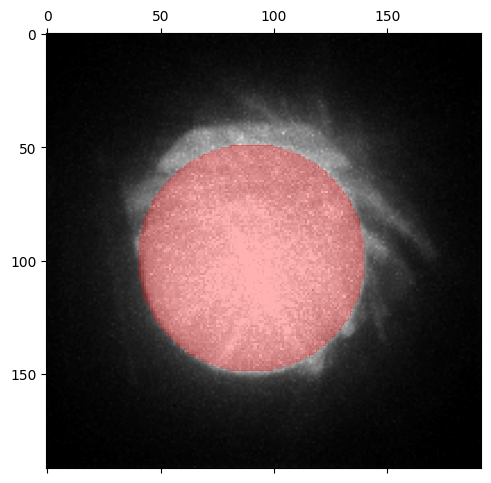

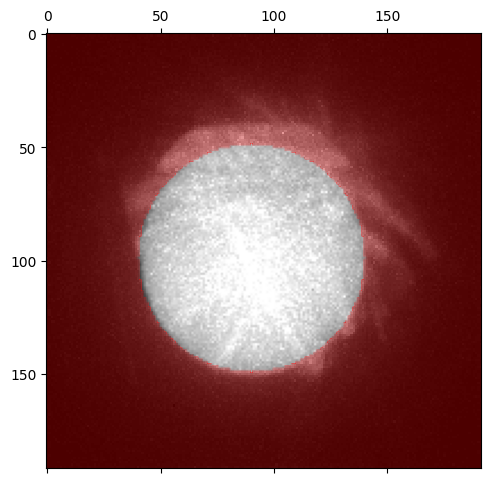

In [30]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (99,90)

# set the geometries
radius_bf = 50
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
dc_bin_2.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
dc_bin_2.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

In [10]:
datacube.calibration.set_R_pixel_size(0.1316)

In [24]:
datacube.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:     0.29687415220228686
             R_pixel_size:     0.1316
             Q_pixel_units:    mrad
             R_pixel_units:    A
             QR_flip:          False
             _root_treepath:   
)

In [25]:
dc_bin_4 = datacube.copy().bin_Q(4)

In [11]:
geometry_bf

((99, 90), 25)

In [33]:
# Virtual imaging - compute the images

# compute
im_bf = dc_bin_2.get_virtual_image(
    mode = 'circle',
    geometry = ((99,90),5),
    name = 'bright_field_cal',
)


im_adf = dc_bin_2.get_virtual_image(
    mode = 'circle',
    geometry = ((99,90),2),
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field radius 5 (BF) ','Bright Field radius 2 (BF)'],
    axsize = (5,8),
)

100%|██████████| 65536/65536 [00:02<00:00, 22000.83it/s]


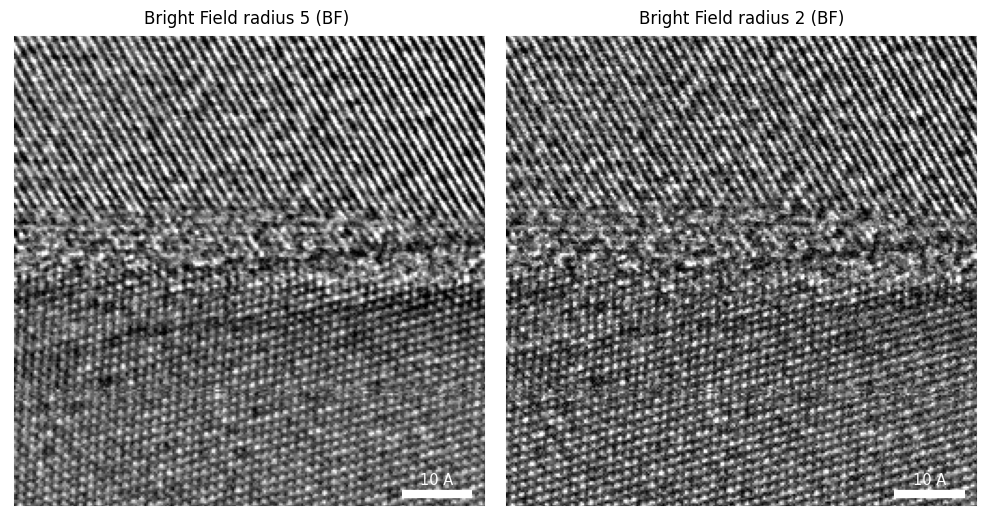

In [34]:
plt.show()

In [7]:
raise Exception("Not implemented")

Exception: Not implemented

In [ ]:
d = datacube

select_loc = 20 #bottom left corner of the window to select
select_window = 100 #size of the window to select
data_partial = d.data[select_loc:select_loc+select_window,
                      select_loc:select_loc+select_window,
                      :,:]
datacube_partial = p4.DataCube(data = data_partial, calibration=d.calibration)


In [ ]:

p4.save(
    data = datacube_partial,
    filepath = path + f'{name}_partial_loc{select_loc}_w{select_window}.h5',
    mode = 'overwrite',
)
del datacube_partial